# Overloading & Overriding

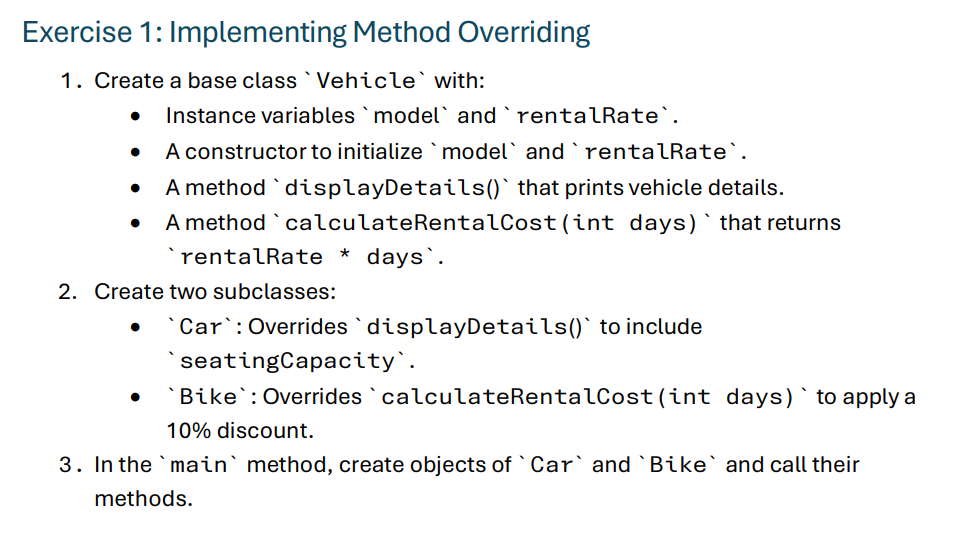

In [11]:
class Vehicle {
    String model;
    double rentalRate;

    public Vehicle(String model, double rentalRate) {
        this.model = model;
        this.rentalRate = rentalRate;
    }

    public void displayDetails() {
        System.out.println(
            "Model: " + model + 
            "\nRental Rate: " + rentalRate
            );
    }

    public double calculateRentalCost(int days) {
        return (rentalRate * days);
    }
}

class Car extends Vehicle {
    int seatingCapacity;
    public Car(String model, double rentalRate, int seatingCapacity) {
        super(model, rentalRate);
        this.seatingCapacity = seatingCapacity;
    }
    @Override
    public void displayDetails() {
        System.out.println(
            "Model: " + model + 
            "\nRental Rate: " + rentalRate +
            "\nSeating Capacity: " + seatingCapacity
            );
    }
}

class Bike extends Vehicle {
    public Bike(String model, double rentalRate) {
        super(model, rentalRate);
    }
    @Override
    public double calculateRentalCost(int days) {
        return (0.9 * (rentalRate * days));
    }
}

public class Main {
    public static void main(String[] args) {
        Car myCar = new Car("Truffade Adder", 65.5,  5);
        Bike myBike = new Bike("Bati 801", 25.99);
        myCar.displayDetails();
        System.out.println(myCar.calculateRentalCost(20));
        myBike.displayDetails();
        System.out.println(myBike.calculateRentalCost(20));
    }
}

Main.main(new String[]{})

Model: Truffade Adder
Rental Rate: 65.5
Seating Capacity: 5
1310.0
Model: Bati 801
Rental Rate: 25.99
467.82


## Exercise 1: Implementing Method Overriding
```java
class Vehicle {
    protected String model;
    protected double rentalRate;
    public Vehicle(String model, double rentalRate) {
        this.model = model;
        this.rentalRate = rentalRate;
    }
    public void displayDetails() {
        System.out.println("Vehicle Model: " + model +
        ", Rental Rate: $" + rentalRate + " per day");
    }
    public double calculateRentalCost(int days) {
        return rentalRate * days;
    }
}
class Car extends Vehicle {
    private int seatingCapacity;
    public Car(String model, double rentalRate, int seatingCapacity) {
        super(model, rentalRate);
        this.seatingCapacity = seatingCapacity;
    }
    @Override
    public void displayDetails() {
        super.displayDetails();
        System.out.println("Seating Capacity: " + seatingCapacity);
    }
}
class Bike extends Vehicle {
    public Bike(String model, double rentalRate) {
        super(model, rentalRate);
    }
    @Override
    public double calculateRentalCost(int days) {
        return (rentalRate * days) * 0.9; // 10% discount for bikes
    }
}

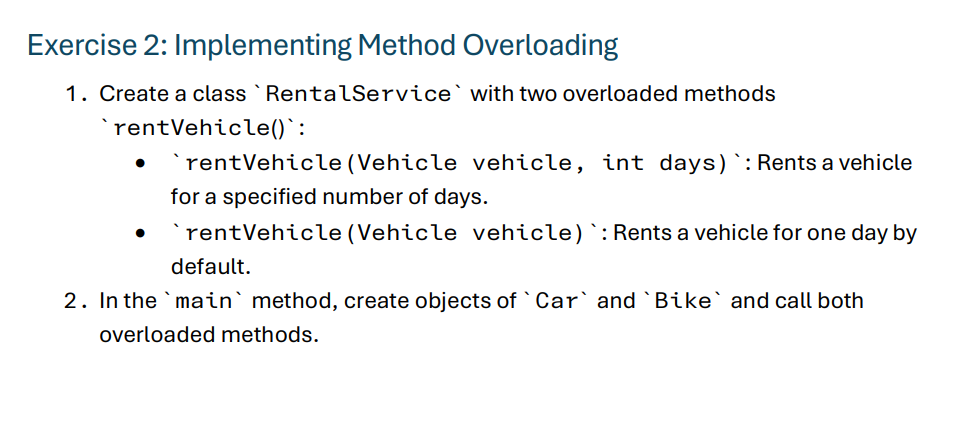

In [15]:
class RentalService {
    public void rentVehicle(Vehicle vehicle, int days) {
        System.out.println(
            vehicle.model + " rented for " + days + "days."
            );
    }
    public void rentVehicle(Vehicle vehicle) {
        System.out.println(
            vehicle.model + " rented for 1 day."
            );
    }
}

public class Main {
    public static void main(String[] args) {
        Car myCar = new Car("Truffade Adder", 65.5,  5);
        Bike myBike = new Bike("Bati 801", 25.99);
        RentalService myRentalService = new RentalService();
        myRentalService.rentVehicle(myCar, 12);
        myRentalService.rentVehicle(myBike);
    }
}

Main.main(new String[]{});

Truffade Adder rented for 12days.
Bati 801 rented for 1 day.


## Exercise 2: Implementing Method Overloading
```java
class RentalService {
    public void rentVehicle(Vehicle vehicle, int days) {
        System.out.println("Renting a vehicle for " + days +
        " days. Total cost: $" +
        vehicle.calculateRentalCost(days));
    }
    public void rentVehicle(Vehicle vehicle) {
        rentVehicle(vehicle, 1); // Default rental for one day
    }
}
```

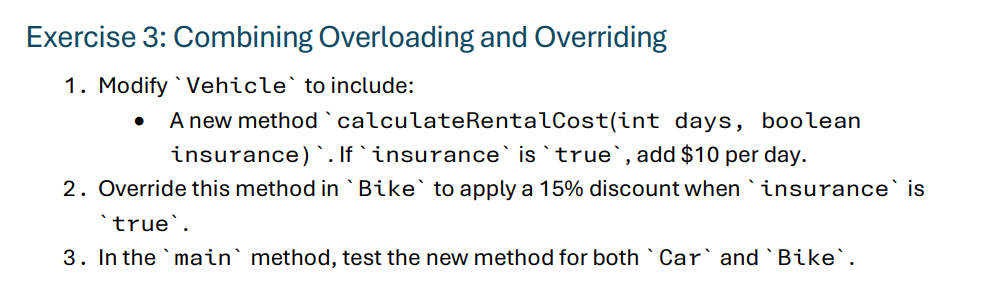

In [30]:
class Vehicle {
    String model;
    double rentalRate;

    public Vehicle(String model, double rentalRate) {
        this.model = model;
        this.rentalRate = rentalRate;
    }

    public void displayDetails() {
        System.out.println(
            "Model: " + model + 
            "\nRental Rate: " + rentalRate
            );
    }

    public double calculateRentalCost(int days) {
        return (rentalRate * days);
    }

    public double calculateRentalCost(int days, boolean insurance) {
        if (insurance) {
            return (calculateRentalCost(days) + 10 * days);
        }
        else {
            return (calculateRentalCost(days));
        }
    }
}

class Car extends Vehicle {
    int seatingCapacity;
    public Car(String model, double rentalRate, int seatingCapacity) {
        super(model, rentalRate);
        this.seatingCapacity = seatingCapacity;
    }
    @Override
    public void displayDetails() {
        System.out.println(
            "Model: " + model + 
            "\nRental Rate: " + rentalRate +
            "\nSeating Capacity: " + seatingCapacity
            );
    }
}

class Bike extends Vehicle {
    public Bike(String model, double rentalRate) {
        super(model, rentalRate);
    }
    @Override
    public double calculateRentalCost(int days) {
        return (0.9 * (rentalRate * days));
    }
    @Override
    public double calculateRentalCost(int days, boolean insurance) {
        if (insurance) {
            return (super.calculateRentalCost(days, insurance) * 0.85);
        }
        else {
            return (calculateRentalCost(days));
        }
    }
}

class RentalService {
    public void rentVehicle(Vehicle vehicle, int days) {
        System.out.println("Renting a vehicle for " + days +
        " days. Total cost: $" +
        vehicle.calculateRentalCost(days));
    }
    public void rentVehicle(Vehicle vehicle) {
        rentVehicle(vehicle, 1); // Default rental for one day
    }
    public void rentVehicle(Vehicle vehicle, int days, boolean insurance) {
        System.out.println(
        "Renting a vehicle for " + days +
        " days. Total cost: $" +
        vehicle.calculateRentalCost(days, insurance) +
        " (insurance = " + insurance + ")"
        );
    }
}

public class Main {
    public static void main(String[] args) {
        Car myCar = new Car("Truffade Adder", 65.5,  5);
        Bike myBike = new Bike("Bati 801", 25.99);
        RentalService myRentalService = new RentalService();
        myRentalService.rentVehicle(myCar, 15, true); 
        myRentalService.rentVehicle(myCar, 15, false); 
        myRentalService.rentVehicle(myBike, 15, true); 
        myRentalService.rentVehicle(myBike, 15, false); 
    }
}

Main.main(new String[]{})

Renting a vehicle for 15 days. Total cost: $1132.5 (insurance = true)
Renting a vehicle for 15 days. Total cost: $982.5 (insurance = false)
Renting a vehicle for 15 days. Total cost: $425.73524999999995 (insurance = true)
Renting a vehicle for 15 days. Total cost: $350.86499999999995 (insurance = false)


## Exercise 3: Combining Overloading and Overriding
```java
class Vehicle {
    public double calculateRentalCost(int days, boolean insurance) {
        double total = rentalRate * days;
    if (insurance) {
        total += 10 * days;
    }
        return total;
    }
}
class Bike extends Vehicle {
    @Override
    public double calculateRentalCost(int days, boolean insurance) {
        double total = (rentalRate * days) * 0.85; // 15% discount
        if (insurance) {
            total += 10 * days;
        }
    return total;
    }
}

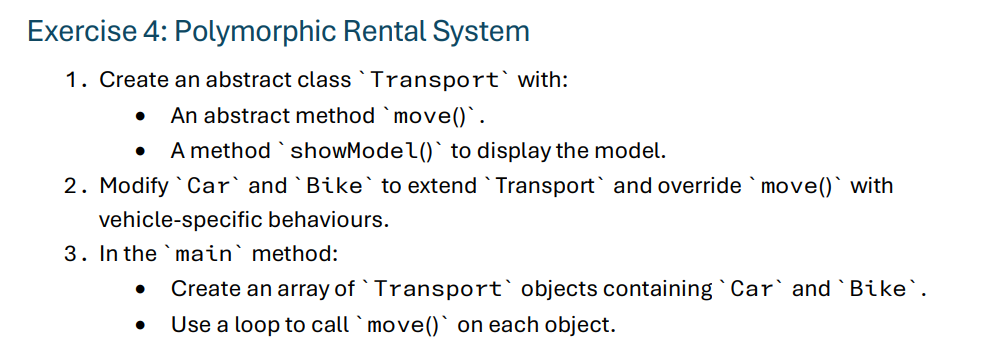

In [38]:
abstract class Transport {
    String model;
    
    abstract void move();

    public void showModel() {
        System.out.println(
            "Model: " + this.model
        );
    }
}

class Car extends Transport {
    public Car(String model) {
        this.model = model;
    }
    @Override
    public void move() {
        System.out.println("Car is moving");
    }
}

class Bike extends Transport {
    public Bike(String model) {
        this.model = model;
    }
    @Override
    public void move() {
        System.out.println("Bike is moving");
    }
}

public class Main {
    public static void main(String[] args) {
        Car myCar = new Car("Truffade Adder");
        Bike myBike = new Bike("Bati 801");
        Transport[] transportArr = new Transport[2];     
        transportArr[0] = myCar;
        transportArr[1] = myBike;
        for (Transport vehicle : transportArr) {
            vehicle.move();
        }
    }
}

Main.main(new String[]{})

Car is moving
Bike is moving


## Exercise 4: Polymorphic Rental System
```java
abstract class Transport {
    String model;
    public Transport(String model) {
        this.model = model;
    }
    abstract void move();
    public void showModel() {
        System.out.println("Model: " + model);
    }
}
class Car extends Transport {
    public Car(String model) {
        super(model);
    }
    @Override
    void move() {
        System.out.println(model + " is driving.");
    }
}
class Bike extends Transport {
    public Bike(String model) {
        super(model);
    }
    @Override
    void move() {
        System.out.println(model + " is riding.");
    }
}
```

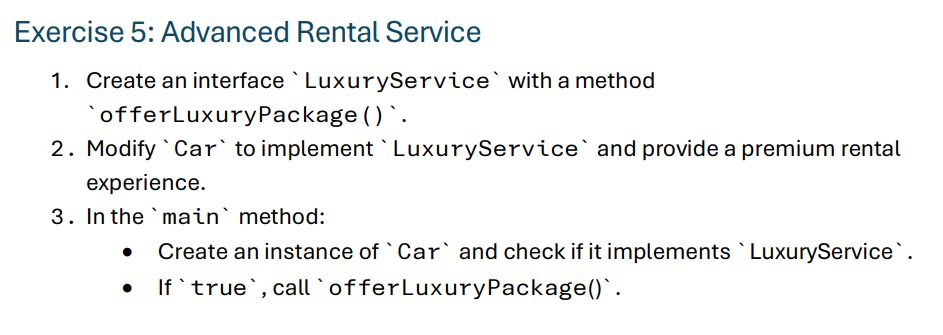

In [41]:
interface LuxuryService {
    void offerLuxuryPackage();
}

class Car extends Transport implements LuxuryService {
    public Car(String model) {
        this.model = model;
    }
    @Override
    void move() {
        System.out.println(model + " is driving.");
    }
    @Override
    public void offerLuxuryPackage() {
        System.out.println("A luxury package is available for " + this.model);
    }
}

public class Main {
    public static void main(String[] args) {
        Car myCar = new Car("Truffade Adder");
        if (myCar instanceof LuxuryService) {
            myCar.offerLuxuryPackage();
        }
    }
}

Main.main(new String[]{})

A luxury package is available for Truffade Adder


## Exercise 5: Advanced Rental Service
```java
interface LuxuryService {
    void offerLuxuryPackage();
}
class Car extends Vehicle implements LuxuryService {
    public Car(String model, double rentalRate) {
        super(model, rentalRate);
    }
    @Override
    public void offerLuxuryPackage() {
        System.out.println(model + " includes a luxury package: " +
        "leather seats, free WiFi, and a chauffeur.");
    }
}

# Upcasting and Downcasting

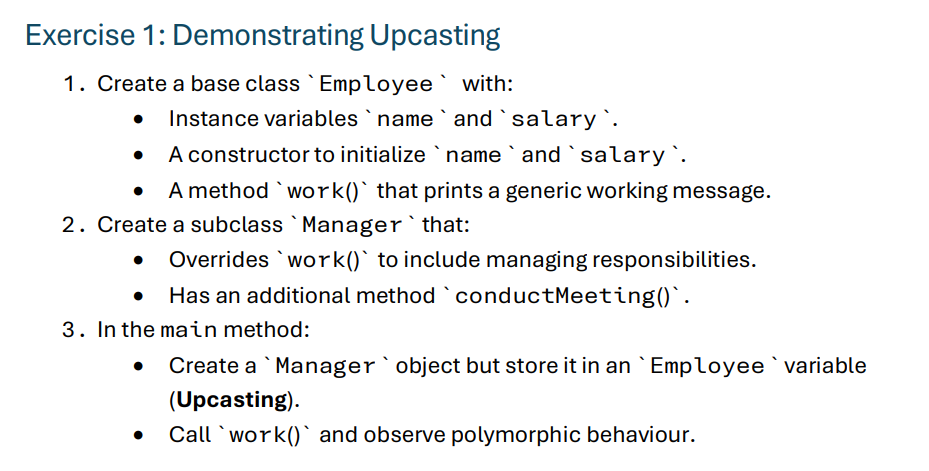

In [54]:
class Employee {
    String name;
    double salary;

    public Employee(String name, double salary){
        this.name = name;
        this.salary = salary;
    }

    public void work() {
        System.out.println(this.name + " is sitting at a computer, replying to emails.");
    }
}

class Manager extends Employee {
    public Manager(String name, double salary) {
        super(name, salary);
    }
    @Override
    public void work() {
        System.out.println(name + " is micro-managing for no reason");
    }
    public void conductMeeting() {
        System.out.println(name + " conducted a meeting, this could have been an email...");
    }
}

public class Main {
    public static void main(String[] args) {
        Employee myManager = new Manager("Cuddy", 12000.0);
        myManager.work();
    }
}

Main.main(new String[]{})

Cuddy is micro-managing for no reason


## Exercise 1: Demonstrating Upcasting
```java
class Employee {
    protected String name;
    protected double salary;
    public Employee(String name, double salary) {
        this.name = name;
        this.salary = salary;
    }
    public void work() {
        System.out.println(name + " is working.");
    }
}
class Manager extends Employee {
    public Manager(String name, double salary) {
        super(name, salary);
    }
    @Override
    public void work() {
        System.out.println(name + " is managing a team.");
    }
    public void conductMeeting() {
        System.out.println(name + " is conducting a meeting.");
    }
}
public class UpcastingExample {
    public static void main(String[] args) {
        Employee emp = new Manager("Alice", 80000); // Upcasting
        emp.work(); // Calls overridden method in Manager
    }
}
```

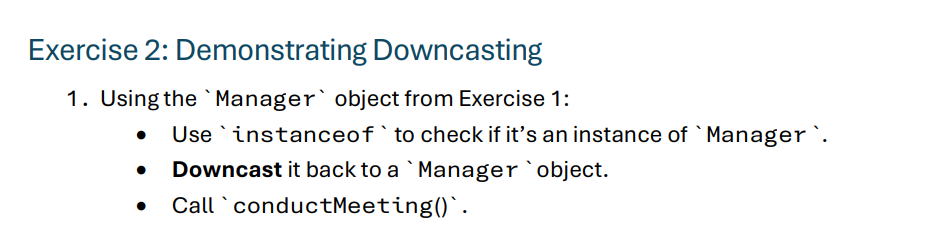

In [55]:
public class Main {
    public static void main(String[] args) {
        Employee myEmployee = new Manager("Cuddy", 12000.0);
        if (myEmployee instanceof Manager) {
            Manager myManager = (Manager) myEmployee;
            myManager.conductMeeting();
        }
    }
}

Main.main(new String[]{})

Cuddy conducted a meeting, this could have been an email...


## Exercise 2: Demonstrating Downcasting
```java
public class DowncastingExample {
    public static void main(String[] args) {
        Employee emp = new Manager("Alice", 80000);
        if (emp instanceof Manager) {
            Manager mgr = (Manager) emp; // Downcasting
            mgr.conductMeeting();
        }
    }
}
```

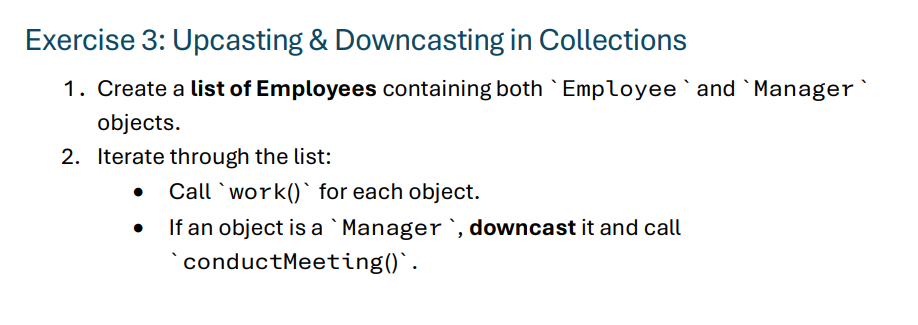

In [57]:
Employee[] employeeList = new Employee[5];
employeeList[0] = new Manager("Manager1", 100000);
employeeList[1] = new Manager("Manager2", 110000);
employeeList[2] = new Employee("Employee1", 10000);
employeeList[3] = new Employee("Employee2", 14000);
employeeList[4] = new Manager("Manager3", 90000);

for (Employee employee : employeeList) {
    employee.work();
    if (employee instanceof Manager) {
        Manager myManager = (Manager) employee;
        myManager.conductMeeting();
    }
}

Manager1 is micro-managing for no reason
Manager1 conducted a meeting, this could have been an email...
Manager2 is micro-managing for no reason
Manager2 conducted a meeting, this could have been an email...
Employee1 is sitting at a computer, replying to emails.
Employee2 is sitting at a computer, replying to emails.
Manager3 is micro-managing for no reason
Manager3 conducted a meeting, this could have been an email...


## Exercise 3: Upcasting & Downcasting in Collections
```java
import java.util.ArrayList;
import java.util.List;
public class EmployeeCollectionExample {
    public static void main(String[] args) {
        List<Employee> employees = new ArrayList<>();
        employees.add(new Employee("Bob", 50000));
        employees.add(new Manager("Alice", 80000));
        for (Employee emp : employees) {
            emp.work();
            if (emp instanceof Manager) {
                ((Manager) emp).conductMeeting();
            }
        }
    }
}
```

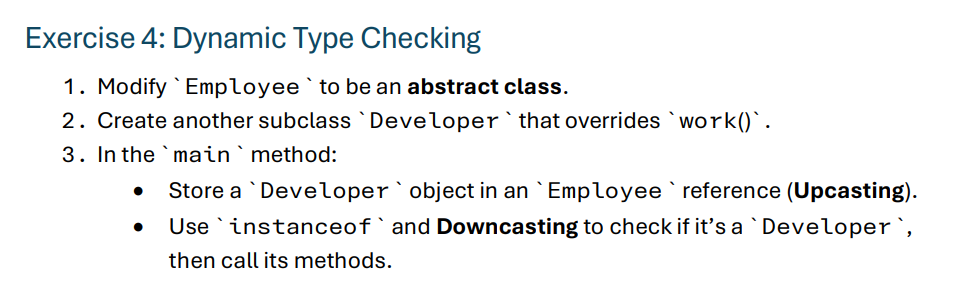

In [59]:
abstract class Employee {
    String name;
    double salary;

    public Employee(String name, double salary){
        this.name = name;
        this.salary = salary;
    }

    public void work() {
        System.out.println(this.name + " is sitting at a computer, replying to emails.");
    }
}

class Manager extends Employee {
    public Manager(String name, double salary) {
        super(name, salary);
    }
    @Override
    public void work() {
        System.out.println(name + " is micro-managing for no reason");
    }
    public void conductMeeting() {
        System.out.println(name + " conducted a meeting, this could have been an email...");
    }
}

class Developer extends Employee {
    public Developer(String name, double salary) {
        super(name, salary);
    }
    public void work() {
        System.out.println(name + " is burning through Claude tokens.");
    }
}

public class Main {
    public static void main(String[] args) {
        Employee emp = new Developer("Yang Long", 50000);
        if (emp instanceof Developer) {
            Developer myDev = (Developer) emp;
            myDev.work();
        }
    }
}

Main.main(new String[]{})

Yang Long is burning through Claude tokens.


## Exercise 4: Dynamic Type Checking
```java
abstract class Employee {
    protected String name;
    protected double salary;
    public Employee(String name, double salary) {
        this.name = name;
        this.salary = salary;
    }
    public abstract void work();
}
class Developer extends Employee {
    public Developer(String name, double salary) {
        super(name, salary);
    }
    @Override
    public void work() {
        System.out.println(name + " is coding.");
    }
}
public class DynamicTypeExample {
    public static void main(String[] args) {
        Employee emp = new Developer("John", 70000);
        emp.work();
        if (emp instanceof Developer) {
            System.out.println("This is a Developer.");
        }
    }
}

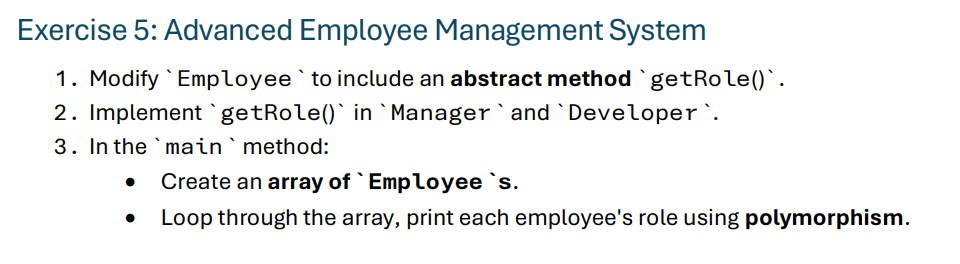

In [61]:
abstract class Employee {
    String name;
    double salary;

    public Employee(String name, double salary){
        this.name = name;
        this.salary = salary;
    }

    abstract void work();

    abstract String getRole();
}

class Manager extends Employee {
    public Manager(String name, double salary) {
        super(name, salary);
    }
    @Override
    public void work() {
        System.out.println(name + " is micro-managing for no reason");
    }
    public void conductMeeting() {
        System.out.println(name + " conducted a meeting, this could have been an email...");
    }
    @Override
    public String getRole() {
        return "Manager";
    }
}

class Developer extends Employee {
    public Developer(String name, double salary) {
        super(name, salary);
    }
    public void work() {
        System.out.println(name + " is burning through Claude tokens.");
    }
    @Override
    public String getRole() {
        return "Developer";
    }
}

public class Main {
    public static void main(String[] args) {
        Employee[] employeeList = new Employee[5];
        employeeList[0] = new Manager("Manager1", 100000);
        employeeList[1] = new Manager("Manager2", 110000);
        employeeList[2] = new Developer("Dev1", 10000);
        employeeList[3] = new Manager("Manager3", 90000);
        employeeList[4] = new Developer("Dev2", 14000);

        for (Employee emp : employeeList) {
            System.out.println(emp.name + " is a " + emp.getRole());
        }
    }
}

Main.main(new String[]{})

Manager1 is a Manager
Manager2 is a Manager
Dev1 is a Developer
Manager3 is a Manager
Dev2 is a Developer


## Exercise 5: Advanced Employee Management System
```java
abstract class Employee {
    protected String name;
    protected double salary;
    public Employee(String name, double salary) {
        this.name = name;
        this.salary = salary;
    }
    public abstract void work();
    public abstract String getRole();
}
class Manager extends Employee {
    public Manager(String name, double salary) {
        super(name, salary);
    }
    @Override
    public void work() {
        System.out.println(name + " is managing a team.");
    }
    @Override
    public String getRole() {
        return "Manager";
    }
}
class Developer extends Employee {
    public Developer(String name, double salary) {
        super(name, salary);
    }
    @Override
    public void work() {
        System.out.println(name + " is coding.");
    }
    @Override
    public String getRole() {
        return "Developer";
    }
}
public class EmployeeSystem {
    public static void main(String[] args) {
        Employee[] employees = {
            new Manager("Alice", 90000),
            new Developer("John", 75000)
        };
        
        for (Employee emp : employees) {
            System.out.println(emp.name + " is a " + emp.getRole());
            emp.work();
        }
    }
}
```